In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import re

: 

Distributed Denial of Service: it's a cybersecurity menace which disrupts online services by sending an overwhelming amount of network traffic. These attacks are manually started with botnets that flood the target network. These attacks could have either of the following characteristics:

The botnet sends a massive number of requests to the hosting servers.
The botnet sends a high volume of random data packets, thus incapacitating the network.
These descriptions provide details about various attributes present in the dataset:

ip.src: Source IP address
tcp.srcport: Source port number for TCP (Transmission Control Protocol).
tcp.dstport: Destination port number for TCP.
ip.proto: IP protocol used (e.g., TCP, UDP).
frame.len: Length of the network frame.
tcp.flags.syn: TCP SYN flag.
tcp.flags.reset: TCP RST flag.
tcp.flags.push: TCP PUSH flag.
tcp.flags.ack: TCP ACK flag.
ip.flags.mf: IP More Fragments flag.
ip.flags.df: IP Do Not Fragment flag.
ip.flags.rb: Reserved bits in the IP header.
tcp.seq: TCP sequence number.
tcp.ack: TCP acknowledgment number.
frame.time: Timestamp of the network frame.
Packets: Number of packets in the network frame.
Bytes: Number of bytes in the network frame.
Tx Packets: Number of transmitted packets.
Tx Bytes: Number of transmitted bytes.
Rx Packets: Number of received packets.
Rx Bytes: Number of received bytes.
Label: The label or category assigned to the network event (e.g., 'DDoS-PSH-ACK', 'Benign', 'DDoS-ACK').

## Data Exploration & Cleaning:

In [ ]:
ddos_data=pd.read_csv(r'C:\Users\Okeoma\Desktop\DDOS_Model\mlops-project-main\source dataset\APA-DDoS-Dataset.csv')
ddos_data

: 

In [7]:
ddos_data.columns

Index(['ip.src', 'ip.dst', 'tcp.srcport', 'tcp.dstport', 'ip.proto',
       'frame.len', 'tcp.flags.syn', 'tcp.flags.reset', 'tcp.flags.push',
       'tcp.flags.ack', 'ip.flags.mf', 'ip.flags.df', 'ip.flags.rb', 'tcp.seq',
       'tcp.ack', 'frame.time', 'Packets', 'Bytes', 'Tx Packets', 'Tx Bytes',
       'Rx Packets', 'Rx Bytes', 'Label'],
      dtype='object')

In [8]:
ddos_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151200 entries, 0 to 151199
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ip.src           151200 non-null  object
 1   ip.dst           151200 non-null  object
 2   tcp.srcport      151200 non-null  int64 
 3   tcp.dstport      151200 non-null  int64 
 4   ip.proto         151200 non-null  int64 
 5   frame.len        151200 non-null  int64 
 6   tcp.flags.syn    151200 non-null  int64 
 7   tcp.flags.reset  151200 non-null  int64 
 8   tcp.flags.push   151200 non-null  int64 
 9   tcp.flags.ack    151200 non-null  int64 
 10  ip.flags.mf      151200 non-null  int64 
 11  ip.flags.df      151200 non-null  int64 
 12  ip.flags.rb      151200 non-null  int64 
 13  tcp.seq          151200 non-null  int64 
 14  tcp.ack          151200 non-null  int64 
 15  frame.time       151200 non-null  object
 16  Packets          151200 non-null  int64 
 17  Bytes     

In [9]:
ddos_data.describe()

,tcp.srcport,tcp.dstport,ip.proto,frame.len,tcp.flags.syn,tcp.flags.reset,tcp.flags.push,tcp.flags.ack,ip.flags.mf,ip.flags.df,ip.flags.rb,tcp.seq,tcp.ack,Packets,Bytes,Tx Packets,Tx Bytes,Rx Packets,Rx Bytes
count,151200.000000,151200.0,151200.0,151200.000000,151200.0,151200.0,151200.000000,151200.0,151200.0,151200.000000,151200.0,151200.0,151200.0,151200.000000,151200.000000,151200.000000,151200.000000,151200.000000,151200.000000
mean,27376.943247,8000.0,6.0,99.025126,0.0,0.0,0.500000,1.0,0.0,0.500000,0.0,1.0,1.0,9.082665,799.422937,5.048776,390.683981,4.033889,408.738955
std,19634.879546,0.0,0.0,71.226673,0.0,0.0,0.500002,0.0,0.0,0.500002,0.0,0.0,0.0,2.129620,373.759057,1.353814,177.223153,0.963107,197.105807
min,1302.000000,8000.0,6.0,54.000000,0.0,0.0,0.000000,1.0,0.0,0.000000,0.0,1.0,1.0,1.000000,54.000000,1.000000,54.000000,0.000000,0.000000
25%,8621.000000,8000.0,6.0,54.000000,0.0,0.0,0.000000,1.0,0.0,0.000000,0.0,1.0,1.0,8.000000,432.000000,4.000000,216.000000,4.000000,216.000000
50%,26263.000000,8000.0,6.0,60.000000,0.0,0.0,0.500000,1.0,0.0,0.500000,0.0,1.0,1.0,10.000000,1101.500000,6.000000,550.000000,4.000000,551.500000
75%,45566.000000,8000.0,6.0,105.000000,0.0,0.0,1.000000,1.0,0.0,1.000000,0.0,1.0,1.0,10.000000,1146.000000,6.000000,560.000000,4.000000,586.000000
max,60998.000000,8000.0,6.0,223.000000,0.0,0.0,1.000000,1.0,0.0,1.000000,0.0,1.0,1.0,20.000000,1229.000000,10.000000,561.000000,10.000000,668.000000


In [10]:
label_counts=ddos_data['Label'].value_counts()
label_counts

Label
Benign          75600
DDoS-PSH-ACK    37800
DDoS-ACK        37800
Name: count, dtype: int64

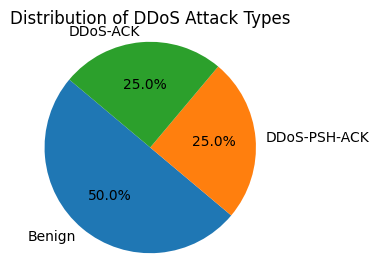

In [11]:
label_counts=ddos_data['Label'].value_counts()
plt.figure(figsize=(3, 3))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of DDoS Attack Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Benign: This label indicates that the network event or traffic is considered normal and does not pose any threat. In other words, it represents benign or legitimate network activity.

DDoS-PSH-ACK: This label represents a specific type of DDoS attack characterized by the TCP flags PSH (Push) and ACK (Acknowledgment). In this type of attack, the attacker sends a high volume of TCP packets with the PSH and ACK flags set, overwhelming the target server or network with a large number of connection requests.

DDoS-ACK: This label indicates another type of DDoS attack where the attacker floods the target server or network with a massive number of TCP packets with only the ACK (Acknowledgment) flag set. This flood of ACK packets consumes resources on the target system, leading to service disruption or denial of service for legitimate users.

The PSH flag indicates that the data should be pushed immediately to the application layer, which can cause the receiving system to process data more rapidly, potentially overwhelming its resources.

In [12]:
ddos_data['ip.dst'].value_counts()

ip.dst
192.168.23.2    151200
Name: count, dtype: int64

In [13]:
ddos_data.drop('ip.dst',axis=1,inplace=True)

In [14]:
constant_features = ddos_data.columns[ddos_data.nunique() == 1]
constant_features

Index(['tcp.dstport', 'ip.proto', 'tcp.flags.syn', 'tcp.flags.reset',
       'tcp.flags.ack', 'ip.flags.mf', 'ip.flags.rb', 'tcp.seq', 'tcp.ack'],
      dtype='object')

In [15]:
print(f'tcp.dstport:{ddos_data["tcp.dstport"].value_counts()}')
print(f'ip.proto:{ddos_data["ip.proto"].value_counts()}')
print(f'tcp.flags.syn:{ddos_data["tcp.flags.syn"].value_counts()}')
print(f'tcp.flags.reset:{ddos_data["tcp.flags.reset"].value_counts()}')
print(f'tcp.flags.ack:{ddos_data["tcp.flags.ack"].value_counts()}')
print(f'ip.flags.mf:{ddos_data["ip.flags.mf"].value_counts()}')
print(f'ip.flags.rb:{ddos_data["ip.flags.rb"].value_counts()}')
print(f'tcp.seq:{ddos_data["tcp.seq"].value_counts()}')
print(f'tcp.ack:{ddos_data["tcp.ack"].value_counts()}')

tcp.dstport:tcp.dstport
8000    151200
Name: count, dtype: int64
ip.proto:ip.proto
6    151200
Name: count, dtype: int64
tcp.flags.syn:tcp.flags.syn
0    151200
Name: count, dtype: int64
tcp.flags.reset:tcp.flags.reset
0    151200
Name: count, dtype: int64
tcp.flags.ack:tcp.flags.ack
1    151200
Name: count, dtype: int64
ip.flags.mf:ip.flags.mf
0    151200
Name: count, dtype: int64
ip.flags.rb:ip.flags.rb
0    151200
Name: count, dtype: int64
tcp.seq:tcp.seq
1    151200
Name: count, dtype: int64
tcp.ack:tcp.ack
1    151200
Name: count, dtype: int64


In [16]:
ddos_data['frame.time'].value_counts()

frame.time
16-Jun 2020 20:18:15.071112000 Mountain Daylight Time    1
16-Jun 2020 22:05:19.560129000 Mountain Daylight Time    1
16-Jun 2020 22:05:19.559918000 Mountain Daylight Time    1
16-Jun 2020 22:05:19.559936000 Mountain Daylight Time    1
16-Jun 2020 22:05:19.559951000 Mountain Daylight Time    1
                                                        ..
16-Jun 2020 20:21:44.728999000 Mountain Daylight Time    1
16-Jun 2020 20:21:44.741244000 Mountain Daylight Time    1
16-Jun 2020 20:21:44.759671000 Mountain Daylight Time    1
16-Jun 2020 20:21:44.771122000 Mountain Daylight Time    1
16-Jun 2020 22:10:46.984798000 Mountain Daylight Time    1
Name: count, Length: 151200, dtype: int64

In [20]:
def normalize_time_column():
    ddos_data['frame.time'] = ddos_data['frame.time'].str.replace(' Mountain Daylight Time', '')
    ddos_data['frame.time']=ddos_data['frame.time'].apply(lambda x: re.sub(r'\..*', '',x ))
    ddos_data['frame.time'] = pd.to_datetime(ddos_data['frame.time'], format=' %d-%b %Y %H:%M:%S')
    ddos_data['frame.time'] = ddos_data['frame.time'].dt.tz_localize('UTC').dt.tz_convert('US/Mountain')

normalize_time_column()

In [22]:
connection_by_time=ddos_data[ddos_data['Label']!='Benign'].groupby(['frame.time']).size()
connection_by_time

frame.time
2020-06-16 14:18:15-06:00    5400
2020-06-16 14:19:44-06:00    5400
2020-06-16 14:21:14-06:00    5400
2020-06-16 14:22:39-06:00    1918
2020-06-16 14:22:40-06:00    3482
2020-06-16 14:24:02-06:00    5400
2020-06-16 14:25:27-06:00    5400
2020-06-16 14:26:54-06:00    5400
2020-06-16 15:57:57-06:00    4905
2020-06-16 15:57:58-06:00     495
2020-06-16 15:59:28-06:00    5400
2020-06-16 16:01:09-06:00    5400
2020-06-16 16:03:04-06:00    3630
2020-06-16 16:03:05-06:00    1770
2020-06-16 16:05:19-06:00    5400
2020-06-16 16:07:04-06:00    5400
2020-06-16 16:08:59-06:00    5400
dtype: int64

In [23]:
ddos_data.dtypes

ip.src                                  object
tcp.srcport                              int64
tcp.dstport                              int64
ip.proto                                 int64
frame.len                                int64
tcp.flags.syn                            int64
tcp.flags.reset                          int64
tcp.flags.push                           int64
tcp.flags.ack                            int64
ip.flags.mf                              int64
ip.flags.df                              int64
ip.flags.rb                              int64
tcp.seq                                  int64
tcp.ack                                  int64
frame.time         datetime64[ns, US/Mountain]
Packets                                  int64
Bytes                                    int64
Tx Packets                               int64
Tx Bytes                                 int64
Rx Packets                               int64
Rx Bytes                                 int64
Label        

NameError: name 'connection_by_time_b' is not defined

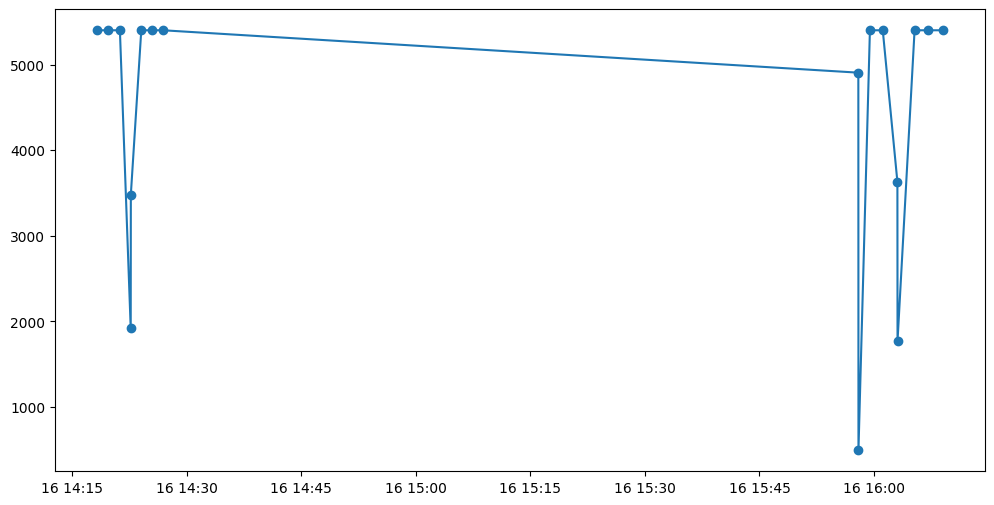

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(connection_by_time.index, connection_by_time.values, marker='o', linestyle='-',label='Non-Benign')
plt.plot(connection_by_time_b.index, connection_by_time_b.values, marker='o', linestyle='-', label='Benign')
plt.title('Benign & non-Benign DDoS Connections Over Time')
plt.xlabel('Time')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [25]:
connection_by_time_different_ip_src=ddos_data[ddos_data['Label']!='Benign'].groupby(['ip.src','frame.time']).size()
connection_by_time_different_ip_src

ip.src        frame.time               
192.168.1.1   2020-06-16 14:18:15-06:00    5400
              2020-06-16 15:57:57-06:00    4905
              2020-06-16 15:57:58-06:00     495
192.168.11.1  2020-06-16 14:25:27-06:00    5400
              2020-06-16 16:07:04-06:00    5400
192.168.14.1  2020-06-16 14:24:02-06:00    5400
              2020-06-16 16:05:19-06:00    5400
192.168.17.1  2020-06-16 14:22:39-06:00    1918
              2020-06-16 14:22:40-06:00    3482
              2020-06-16 16:03:04-06:00    3630
              2020-06-16 16:03:05-06:00    1770
192.168.20.1  2020-06-16 14:26:54-06:00    5400
              2020-06-16 16:08:59-06:00    5400
192.168.4.1   2020-06-16 14:19:44-06:00    5400
              2020-06-16 15:59:28-06:00    5400
192.168.7.1   2020-06-16 14:21:14-06:00    5400
              2020-06-16 16:01:09-06:00    5400
dtype: int64

<Figure size 1000x600 with 0 Axes>

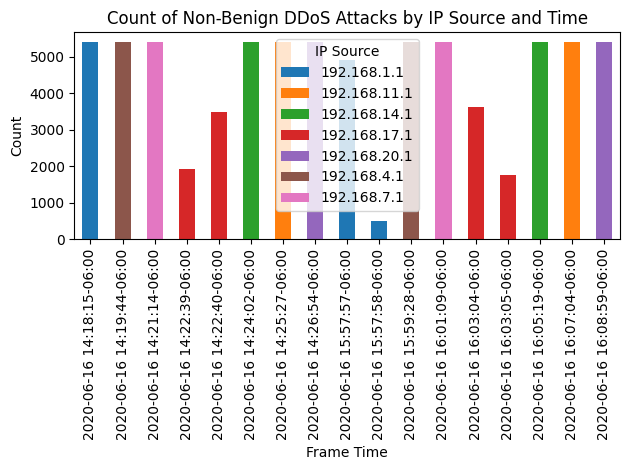

In [26]:
plt.figure(figsize=(10, 6))
connection_by_time_different_ip_src.unstack(level=0).plot(kind='bar', stacked=True)
plt.title('Count of Non-Benign DDoS Attacks by IP Source and Time')
plt.xlabel('Frame Time')
plt.ylabel('Count')
plt.legend(title='IP Source')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [27]:
ddos_data[ddos_data['Label']=='Benign'].groupby(['frame.time','Packets']).size()

frame.time                 Packets
2020-06-16 14:18:22-06:00  10         49
2020-06-16 14:18:23-06:00  10         71
2020-06-16 14:18:24-06:00  10         74
2020-06-16 14:18:25-06:00  10         71
2020-06-16 14:18:26-06:00  10         70
                                      ..
2020-06-16 16:10:42-06:00  10         44
2020-06-16 16:10:43-06:00  10         49
2020-06-16 16:10:44-06:00  10         63
2020-06-16 16:10:45-06:00  10         22
2020-06-16 16:10:46-06:00  10         66
Length: 1186, dtype: int64

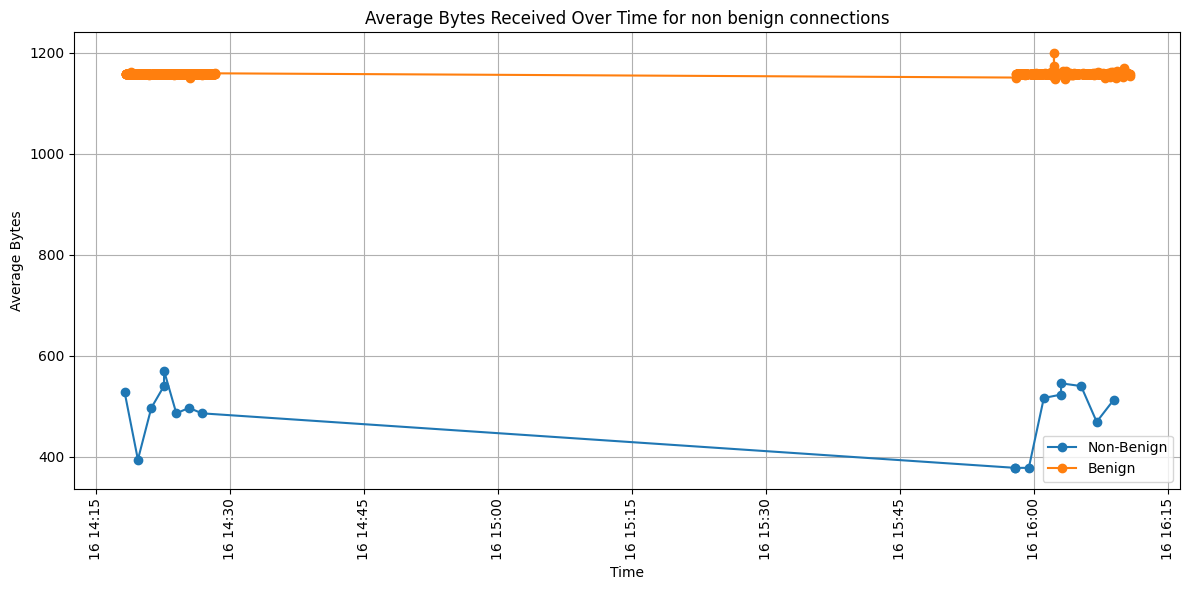

In [28]:
non_benign_data = ddos_data[ddos_data['Label'] != 'Benign']
non_benign_bytes_by_time = non_benign_data.groupby(['frame.time', 'Bytes']).size().reset_index(name='count')
non_benign_bytes_by_time = non_benign_bytes_by_time.groupby('frame.time')['Bytes'].mean()

benign_data = ddos_data[ddos_data['Label'] == 'Benign']

benign_bytes_by_time =benign_data.groupby(['frame.time', 'Bytes']).size().reset_index(name='count')
benign_bytes_by_time = benign_bytes_by_time.groupby('frame.time')['Bytes'].mean()

plt.figure(figsize=(12, 6))
plt.plot(non_benign_bytes_by_time.index, non_benign_bytes_by_time.values, label='Non-Benign', linestyle='-', marker='o')
plt.plot(benign_bytes_by_time.index, benign_bytes_by_time.values, label='Benign', linestyle='-', marker='o')
plt.title('Average Bytes Received Over Time for non benign connections')
plt.xlabel('Time')
plt.ylabel('Average Bytes')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

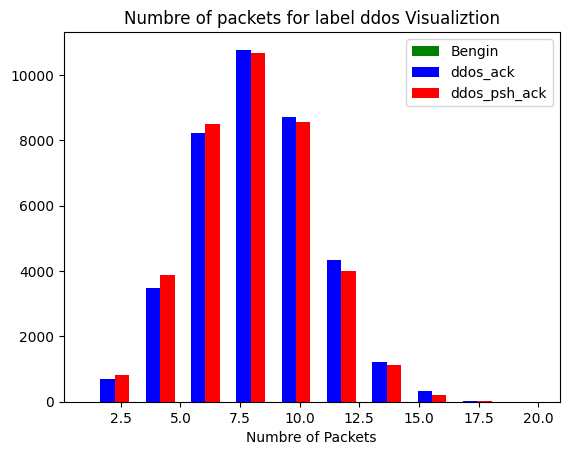

In [29]:
benign=ddos_data[ddos_data['Label']=="Bengin"].Packets
ddos_ack=ddos_data[ddos_data['Label']=="DDoS-ACK"].Packets
ddos_psh_ack=ddos_data[ddos_data['Label']=="DDoS-PSH-ACK"].Packets
plt.xlabel("Numbre of Packets")
plt.ylabel("")
plt.title("Numbre of packets for label ddos Visualiztion")
plt.hist([benign, ddos_ack,ddos_psh_ack], rwidth=0.95, color=['green','blue','red'],label=['Bengin','ddos_ack','ddos_psh_ack'])
plt.legend()

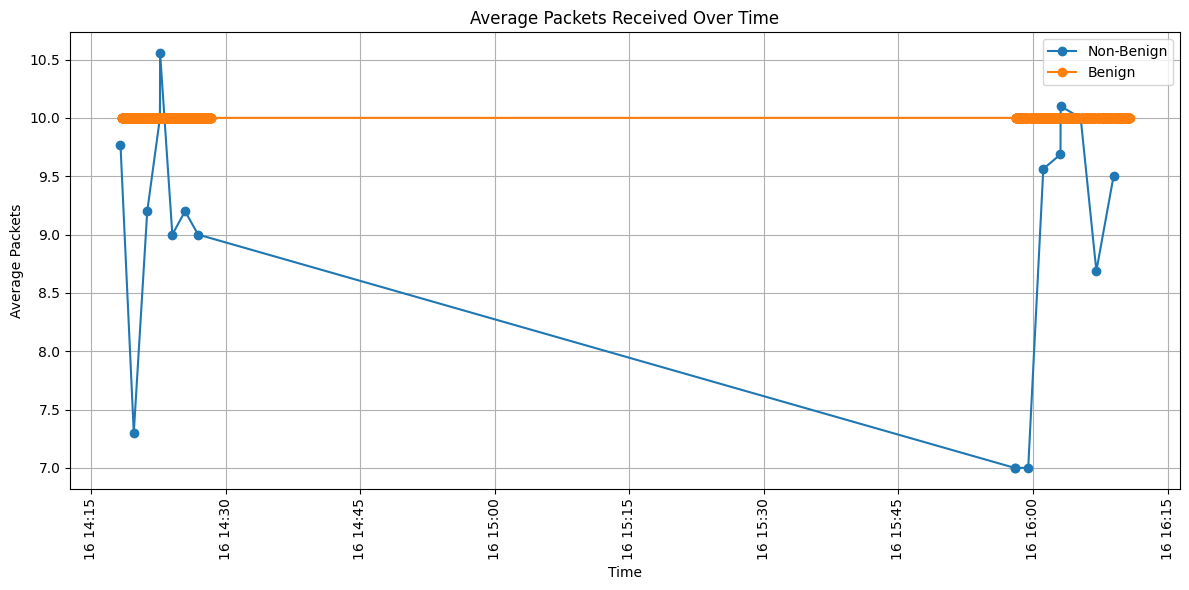

In [30]:
# Filter non-benign and benign data
non_benign_data = ddos_data[ddos_data['Label'] != 'Benign']
benign_data = ddos_data[ddos_data['Label'] == 'Benign']

# Group by 'frame.time' and 'Packets' and calculate the mean for non-benign traffic
non_benign_packets_by_time = non_benign_data.groupby(['frame.time', 'Packets']).size().reset_index(name='count')
non_benign_packets_by_time = non_benign_packets_by_time.groupby('frame.time')['Packets'].mean()

# Group by 'frame.time' and 'Packets' and calculate the mean for benign traffic
benign_packets_by_time = benign_data.groupby(['frame.time', 'Packets']).size().reset_index(name='count')
benign_packets_by_time = benign_packets_by_time.groupby('frame.time')['Packets'].mean()

# Plotting the line chart for non-benign and benign traffic
plt.figure(figsize=(12, 6))
plt.plot(non_benign_packets_by_time.index, non_benign_packets_by_time.values, label='Non-Benign', linestyle='-', marker='o')
plt.plot(benign_packets_by_time.index, benign_packets_by_time.values, label='Benign', linestyle='-', marker='o')
plt.title('Average Packets Received Over Time')
plt.xlabel('Time')
plt.ylabel('Average Packets')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

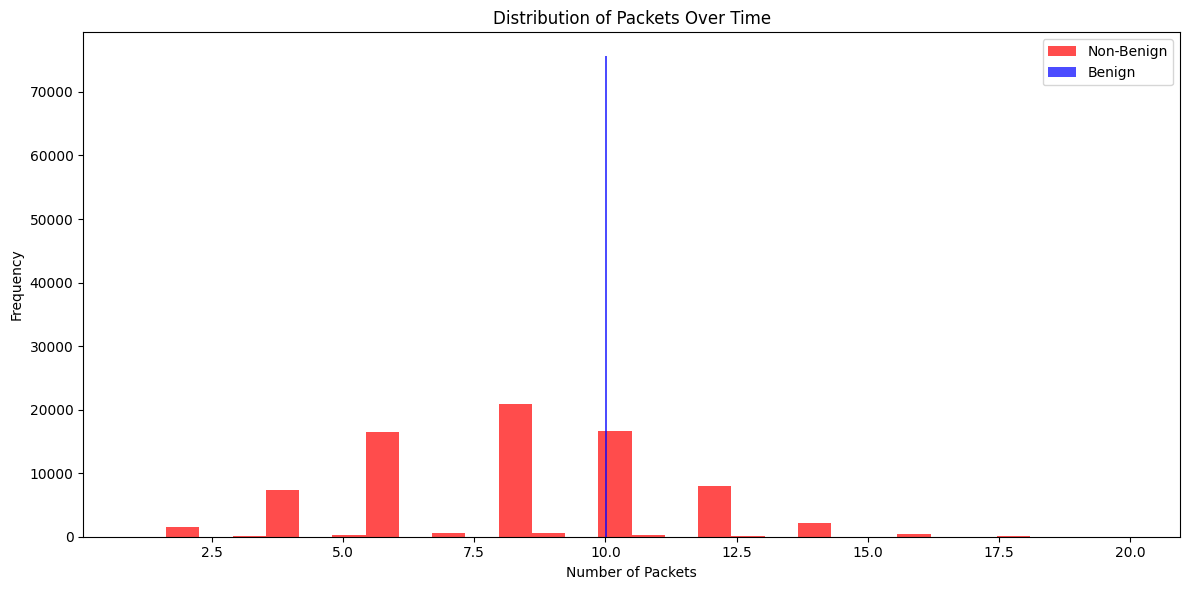

In [31]:
# Filter non-benign and benign data
non_benign_data = ddos_data[ddos_data['Label'] != 'Benign']
benign_data = ddos_data[ddos_data['Label'] == 'Benign']

# Plot histograms for non-benign and benign connections
plt.figure(figsize=(12, 6))
plt.hist(non_benign_data['Packets'], bins=30, alpha=0.7, color='red', label='Non-Benign')
plt.hist(benign_data['Packets'], bins=30, alpha=0.7, color='blue', label='Benign')
plt.title('Distribution of Packets Over Time')
plt.xlabel('Number of Packets')
plt.ylabel('Frequency')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
label_counts = ddos_data.groupby(['frame.time','Label']).size().unstack(fill_value=0)
label_counts

Label,Benign,DDoS-ACK,DDoS-PSH-ACK
frame.time,,,
2020-06-16 14:18:15-06:00,0,0,5400
2020-06-16 14:18:22-06:00,49,0,0
2020-06-16 14:18:23-06:00,71,0,0
2020-06-16 14:18:24-06:00,74,0,0
2020-06-16 14:18:25-06:00,71,0,0
...,...,...,...
2020-06-16 16:10:42-06:00,44,0,0
2020-06-16 16:10:43-06:00,49,0,0
2020-06-16 16:10:44-06:00,63,0,0


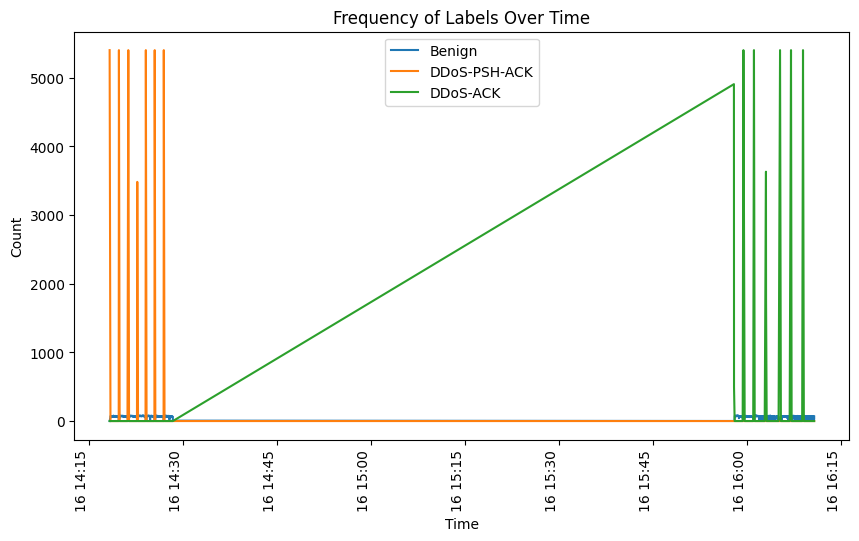

In [34]:
label_counts['Benign'].plot(kind='line', figsize=(10, 6))
label_counts['DDoS-PSH-ACK'].plot(kind='line', figsize=(10, 6))
label_counts['DDoS-ACK'].plot(kind='line', figsize=(10, 6))

plt.title('Frequency of Labels Over Time')
plt.xlabel('Time')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.legend()
plt.show()

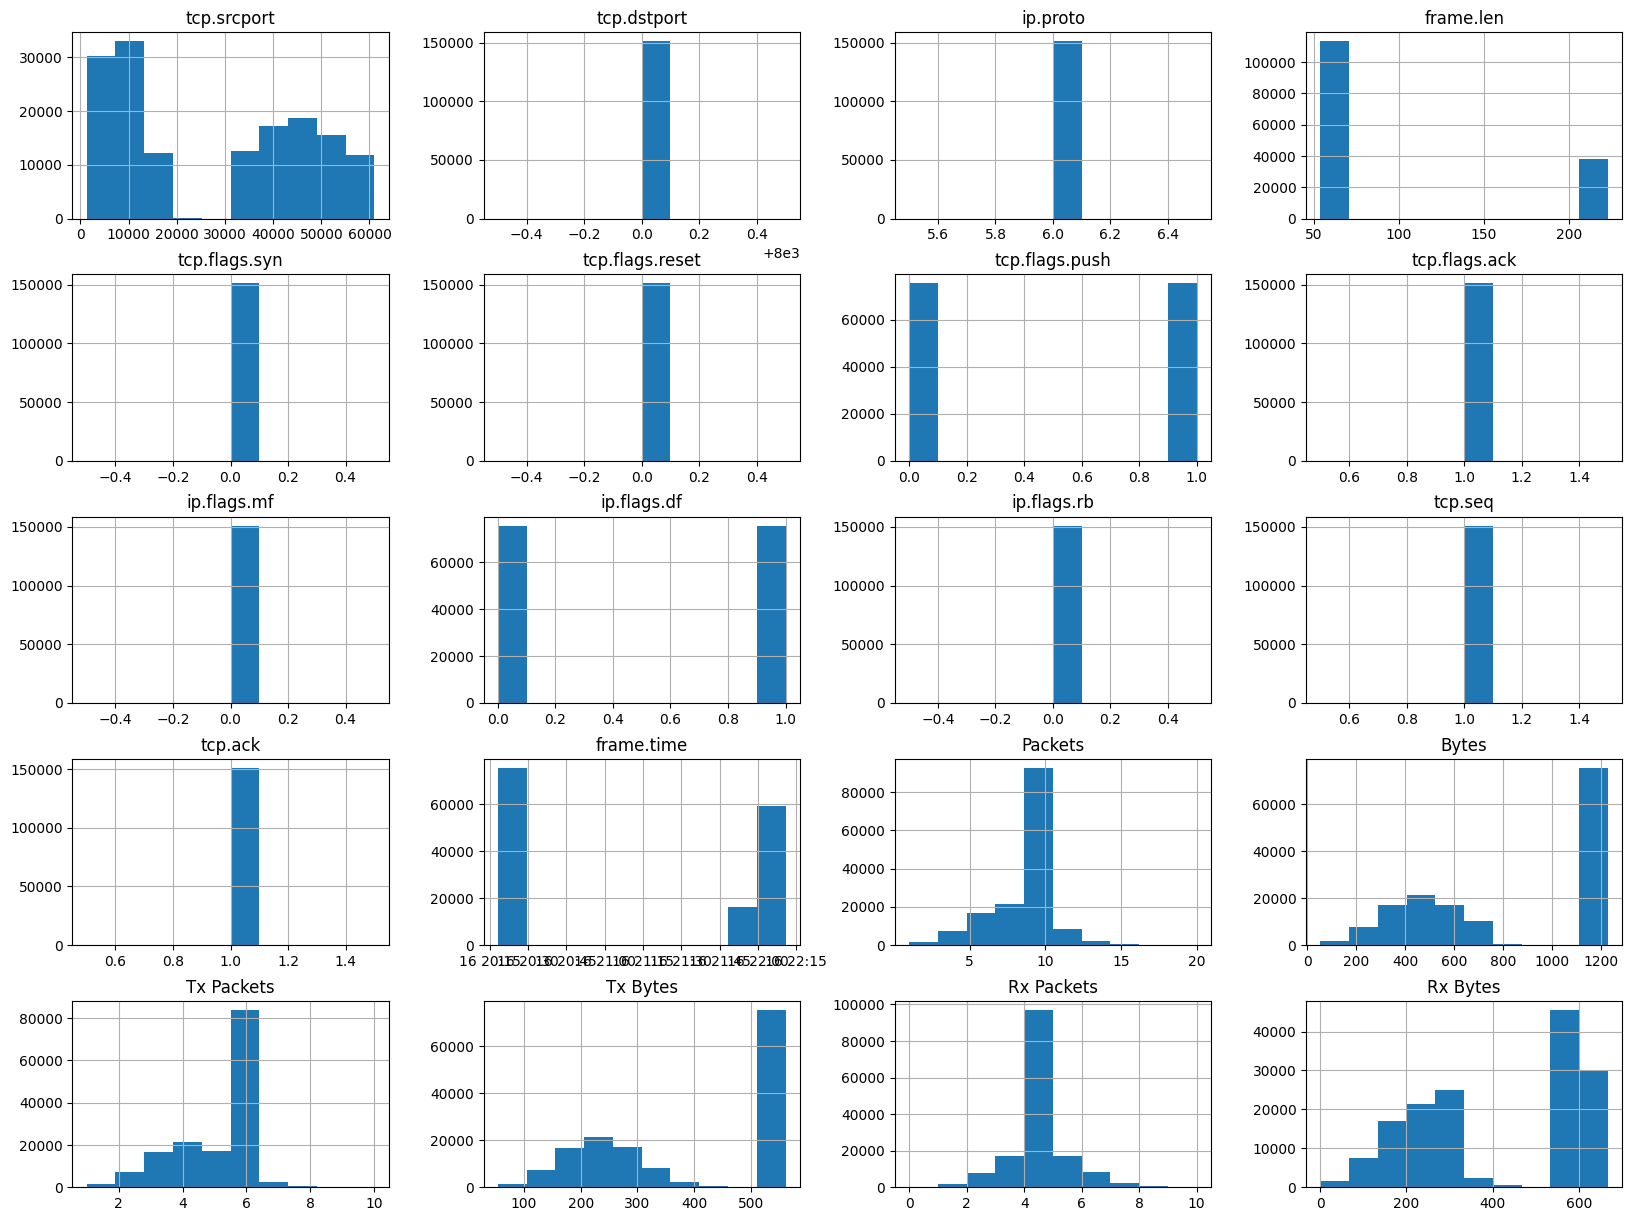

In [35]:
ddos_data.hist(bins =10, figsize=(20, 15))
plt.show()

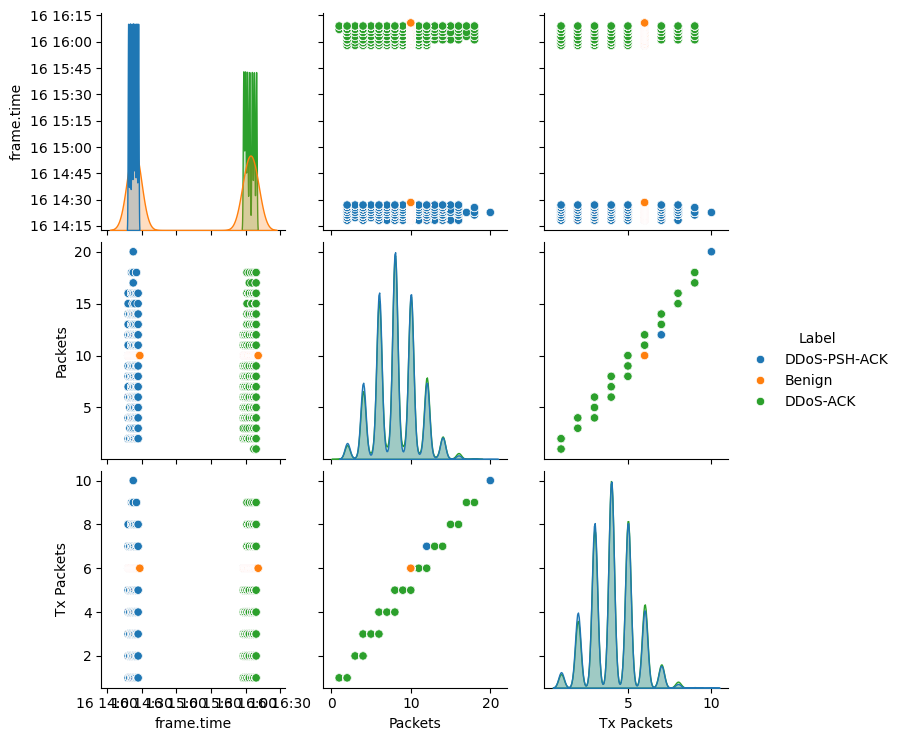

In [36]:
sns.pairplot(ddos_data,hue='Label',vars=['frame.time','Packets','Tx Packets'])

In [37]:
numerical_features = [feature for feature in ddos_data.columns if ddos_data[feature].dtypes != 'O']
numerical_features

['tcp.srcport',
 'tcp.dstport',
 'ip.proto',
 'frame.len',
 'tcp.flags.syn',
 'tcp.flags.reset',
 'tcp.flags.push',
 'tcp.flags.ack',
 'ip.flags.mf',
 'ip.flags.df',
 'ip.flags.rb',
 'tcp.seq',
 'tcp.ack',
 'frame.time',
 'Packets',
 'Bytes',
 'Tx Packets',
 'Tx Bytes',
 'Rx Packets',
 'Rx Bytes']

In [38]:
categorical_features = [feature for feature in ddos_data.columns if ddos_data[feature].dtypes == 'O']
categorical_features

['ip.src', 'Label']

In [39]:
corr_matrix=ddos_data[numerical_features].corr()
corr_matrix

,tcp.srcport,tcp.dstport,ip.proto,frame.len,tcp.flags.syn,tcp.flags.reset,tcp.flags.push,tcp.flags.ack,ip.flags.mf,ip.flags.df,ip.flags.rb,tcp.seq,tcp.ack,frame.time,Packets,Bytes,Tx Packets,Tx Bytes,Rx Packets,Rx Bytes
tcp.srcport,1.000000,NaN,NaN,0.548713,NaN,NaN,-5.730803e-02,NaN,NaN,9.476358e-01,NaN,NaN,NaN,0.068029,0.403754,0.907529,0.662447,0.904495,-0.038405,0.907632
tcp.dstport,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip.proto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frame.len,0.548713,NaN,NaN,1.000000,NaN,NaN,5.479023e-01,NaN,NaN,6.321406e-01,NaN,NaN,NaN,-0.542009,0.272296,0.606405,0.444159,0.604299,-0.022243,0.606546
tcp.flags.syn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tcp.flags.reset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tcp.flags.push,-0.057308,NaN,NaN,0.547902,NaN,NaN,1.000000e+00,NaN,NaN,-1.392246e-15,NaN,NaN,NaN,-0.997739,-0.016457,-0.005053,-0.014671,-0.006051,-0.015767,-0.004141
tcp.flags.ack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip.flags.mf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip.flags.df,0.947636,NaN,NaN,0.632141,NaN,NaN,-1.392246e-15,NaN,NaN,1.000000e+00,NaN,NaN,NaN,0.008034,0.430752,0.959164,0.702627,0.955951,-0.035187,0.959280


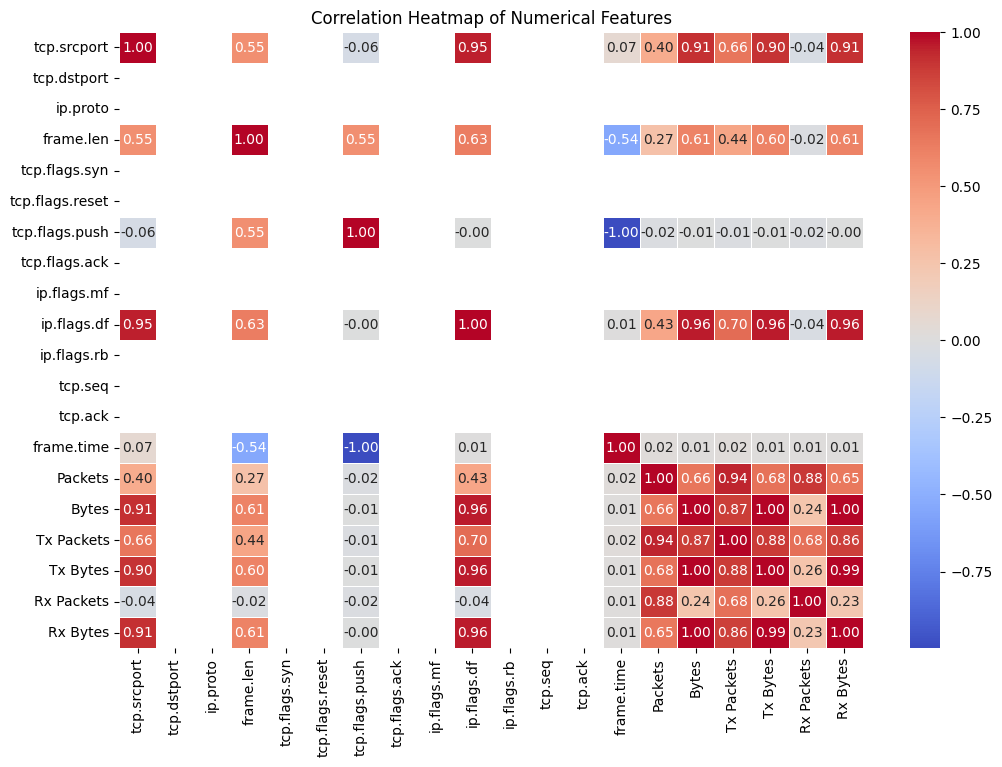

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [41]:
#Let's examine binary columns
binary_features=ddos_data.columns[ddos_data.nunique() == 2]
binary_features

Index(['tcp.flags.push', 'ip.flags.df'], dtype='object')

In [42]:
numerical_features.remove('Tx Bytes')
numerical_features.remove('Rx Bytes')
ddos_data.drop(['Tx Bytes','Rx Bytes'],axis=1, inplace=True)
numerical_features = [feature for feature in numerical_features if feature not in binary_features]

In [47]:
ddos_data.columns

Index(['ip.src', 'tcp.srcport', 'tcp.dstport', 'ip.proto', 'frame.len',
       'tcp.flags.syn', 'tcp.flags.reset', 'tcp.flags.push', 'tcp.flags.ack',
       'ip.flags.mf', 'ip.flags.df', 'ip.flags.rb', 'tcp.seq', 'tcp.ack',
       'frame.time', 'Packets', 'Bytes', 'Tx Packets', 'Rx Packets', 'Label'],
      dtype='object')

c:\Users\Okeoma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=8. All the features will be returned.
  warnings.warn(


In [65]:
X

SelectKBest(score_func=<function mutual_info_classif at 0x0000023C728CD080>)

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, ddos_data['Label'], test_size=0.2, random_state=42)

rand = RandomForestClassifier(n_estimators=100, random_state=42)


rand.fit(X_train, y_train)

rand.score(X_test,y_test)


1.0